# Fetal Health Diagnostic — Two-Stage Cascade XGBoost
Predicts fetal health status (Normal / Suspect / Pathological) from 13 CTG features using a two-stage cascade model.

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib as jbl
import os

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [2]:
# ── Load Data & Define 13 Features ───────────────────────────────────────────
df = pd.read_csv('fetal_health.csv')

final_features = [
    'baseline value',
    'accelerations',
    'fetal_movement',
    'uterine_contractions',
    'light_decelerations',
    'severe_decelerations',
    'prolongued_decelerations',
    'abnormal_short_term_variability',
    'mean_value_of_short_term_variability',
    'percentage_of_time_with_abnormal_long_term_variability',
    'mean_value_of_long_term_variability',
    'histogram_median',
    'histogram_variance'
]

dff = df[final_features].copy()
y   = df[['fetal_health']]

print('Feature set:', dff.columns.tolist())
print('Shape:', dff.shape)
print('\nClass distribution:')
print(y.groupby('fetal_health').size())

Feature set: ['baseline value', 'accelerations', 'fetal_movement', 'uterine_contractions', 'light_decelerations', 'severe_decelerations', 'prolongued_decelerations', 'abnormal_short_term_variability', 'mean_value_of_short_term_variability', 'percentage_of_time_with_abnormal_long_term_variability', 'mean_value_of_long_term_variability', 'histogram_median', 'histogram_variance']
Shape: (2126, 13)

Class distribution:
fetal_health
1.0    1655
2.0     295
3.0     176
dtype: int64


C:\Users\santh\AppData\Local\Temp\ipykernel_31116\717914676.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(dff.values, labels=dff.columns, orientation='horizontal')


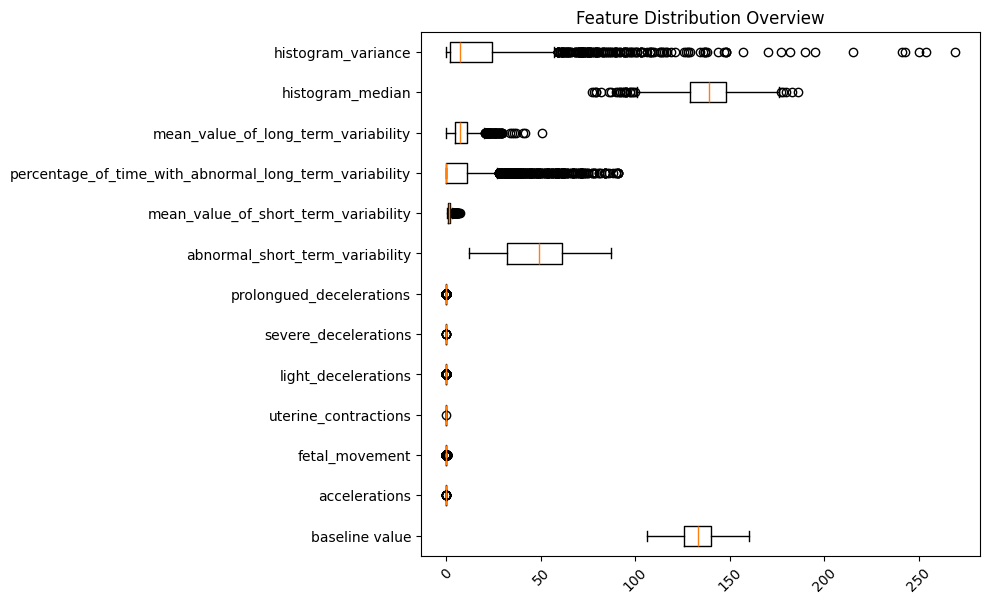

In [3]:
# ── EDA: Feature Boxplot ──────────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
plt.boxplot(dff.values, labels=dff.columns, orientation='horizontal')
plt.title('Feature Distribution Overview')
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

In [4]:
# ── Baseline Model Comparison (Optional) ─────────────────────────────────────
x_train, x_test, y_train, y_test = train_test_split(
    dff, y.values.ravel(), test_size=0.2, random_state=42, stratify=y
)

model_pipeline = {
    'DecisionTree': {
        'model':  DecisionTreeClassifier(random_state=42),
        'params': {'max_depth': [3, 5, 10, 15], 'criterion': ['gini', 'entropy']}
    },
    'RandomForest': {
        'model':  RandomForestClassifier(random_state=42),
        'params': {'n_estimators': [50, 100, 150], 'max_depth': [5, 10, 15]}
    },
    'SVM': {
        'model':  SVC(random_state=42),
        'params': {'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear', 'sigmoid']}
    },
    'XGBoost': {
        'model':  XGBClassifier(objective='multi:softprob', eval_metric='mlogloss', num_class=3, random_state=42),
        'params': {'n_estimators': [50, 100, 150], 'max_depth': [3, 5, 7, 11]}
    }
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, setup in model_pipeline.items():
    grid = GridSearchCV(estimator=setup['model'], param_grid=setup['params'],
                        scoring='f1_macro', cv=cv, n_jobs=-1)
    grid.fit(x_train, y_train - 1)
    print(f'── {name} ──')
    print(f'  Best params : {grid.best_params_}')
    print(f'  F1 (macro)  : {grid.best_score_:.4f}\n')

── DecisionTree ──
  Best params : {'criterion': 'entropy', 'max_depth': 15}
  F1 (macro)  : 0.8765

── RandomForest ──
  Best params : {'max_depth': 10, 'n_estimators': 100}
  F1 (macro)  : 0.9098

── SVM ──
  Best params : {'C': 10, 'kernel': 'rbf'}
  F1 (macro)  : 0.7844

── XGBoost ──
  Best params : {'max_depth': 5, 'n_estimators': 50}
  F1 (macro)  : 0.9246



In [4]:
# ── Train Model A: Gatekeeper (Normal vs At-Risk) ────────────────────────────
y_A = y['fetal_health'].replace({1: 0, 2: 1, 3: 1})

n_normal = (y_A == 0).sum()
n_risk   = (y_A == 1).sum()
ratio    = round(n_normal / n_risk)
print(f'Normal: {n_normal} | Risk: {n_risk} | scale_pos_weight: {ratio}')

X_train, X_test, y_train, y_test = train_test_split(
    dff, y_A, test_size=0.2, random_state=42, stratify=y_A
)

model_A = XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    scale_pos_weight=8,   
    n_estimators=300,
    max_depth=7,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=1,
    gamma=0
)

model_A.fit(X_train, y_train)
print('\nTest set performance:')
print(classification_report(y_test, model_A.predict(X_test), target_names=['Normal', 'Risk']))

model_A.fit(dff, y_A.values.ravel())
print('Model A trained on full data.')

Normal: 1655 | Risk: 471 | scale_pos_weight: 4

Test set performance:
              precision    recall  f1-score   support

      Normal       0.98      0.96      0.97       332
        Risk       0.87      0.95      0.91        94

    accuracy                           0.96       426
   macro avg       0.93      0.95      0.94       426
weighted avg       0.96      0.96      0.96       426

Model A trained on full data.


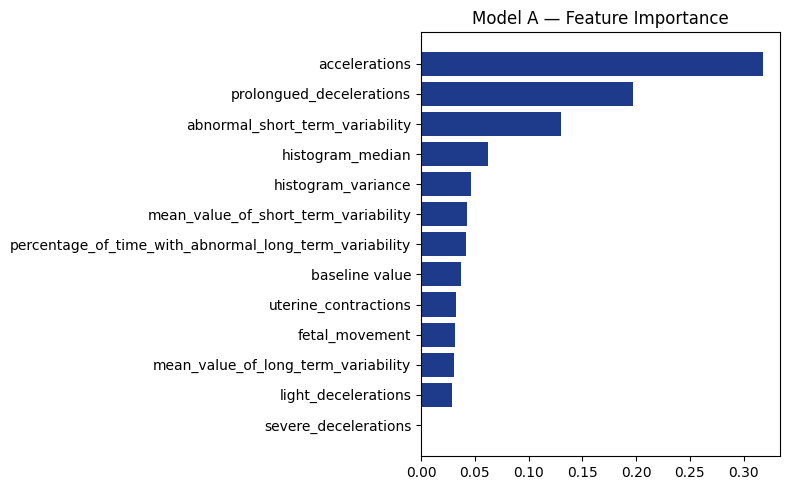

                                               Feature  Importance
                                         accelerations    0.317843
                              prolongued_decelerations    0.197070
                       abnormal_short_term_variability    0.129807
                                      histogram_median    0.062448
                                    histogram_variance    0.046876
                  mean_value_of_short_term_variability    0.043249
percentage_of_time_with_abnormal_long_term_variability    0.042189
                                        baseline value    0.037657
                                  uterine_contractions    0.032464
                                        fetal_movement    0.031221
                   mean_value_of_long_term_variability    0.030637
                                   light_decelerations    0.028539
                                  severe_decelerations    0.000000


In [5]:
# ── Model A: Feature Importance ───────────────────────────────────────────────
imp_df = pd.DataFrame({
    'Feature':    dff.columns.tolist(),
    'Importance': model_A.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(imp_df['Feature'], imp_df['Importance'], color='#1e3a8a')
plt.title('Model A — Feature Importance')
plt.tight_layout()
plt.show()

print(imp_df.sort_values('Importance', ascending=False).to_string(index=False))

In [6]:
# ── Train Model B: Specialist (Suspect vs Pathological) ──────────────────────
risk_mask = y['fetal_health'].isin([2.0, 3.0])
X_B = dff[risk_mask.values].copy()
y_B = y[risk_mask]['fetal_health'].map({2.0: 0, 3.0: 1})

print(f'Suspect: {(y_B==0).sum()} | Pathological: {(y_B==1).sum()}')

model_B = XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05
)
model_B.fit(X_B, y_B.values.ravel())#ly to x_train , y_train
print('Model B trained.')
print(risk_mask.value_counts())# contaiins only the risk and patho values

Suspect: 295 | Pathological: 176
Model B trained.
fetal_health
False    1655
True      471
Name: count, dtype: int64


In [15]:
# X_B
dff[risk_mask.values]

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,histogram_median,histogram_variance
0,120.0,0.000,0.000,0.000,0.000,0.0,0.000,73.0,0.5,43.0,2.4,121.0,73.0
5,134.0,0.001,0.000,0.010,0.009,0.0,0.002,26.0,5.9,0.0,0.0,107.0,170.0
6,134.0,0.001,0.000,0.013,0.008,0.0,0.003,29.0,6.3,0.0,0.0,106.0,215.0
7,122.0,0.000,0.000,0.000,0.000,0.0,0.000,83.0,0.5,6.0,15.6,123.0,3.0
8,122.0,0.000,0.000,0.002,0.000,0.0,0.000,84.0,0.5,5.0,13.6,123.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2086,133.0,0.000,0.003,0.006,0.000,0.0,0.000,74.0,1.3,28.0,3.9,137.0,1.0
2121,140.0,0.000,0.000,0.007,0.000,0.0,0.000,79.0,0.2,25.0,7.2,152.0,2.0
2122,140.0,0.001,0.000,0.007,0.000,0.0,0.000,78.0,0.4,22.0,7.1,151.0,3.0
2123,140.0,0.001,0.000,0.007,0.000,0.0,0.000,79.0,0.4,20.0,6.1,152.0,4.0


In [7]:
# ── Save Models ───────────────────────────────────────────────────────────────
jbl.dump(model_A, 'model_A_gatekeeper.pkl')
jbl.dump(model_B, 'model_B_metamodel.pkl')

if os.path.exists('model_A_gatekeeper.pkl') and os.path.exists('model_B_metamodel.pkl'):
    print('Both models saved successfully.')
else:
    print('Save failed — check working directory.')

Both models saved successfully.


In [ ]:
# ── Validation: Test All Three Classes ───────────────────────────────────────
test_cases = {
    'NORMAL': {
        'baseline value': 130.0, 'accelerations': 0.006, 'fetal_movement': 0.0,
        'uterine_contractions': 0.004, 'light_decelerations': 0.003, 'severe_decelerations': 0.0,
        'prolongued_decelerations': 0.0, 'abnormal_short_term_variability': 20.0,
        'mean_value_of_short_term_variability': 2.5,
        'percentage_of_time_with_abnormal_long_term_variability': 0.0,
        'mean_value_of_long_term_variability': 10.0, 'histogram_median': 132.0, 'histogram_variance': 7.0
    },
    'SUSPECT': {
        'baseline value': 148.0, 'accelerations': 0.001, 'fetal_movement': 0.0,
        'uterine_contractions': 0.007, 'light_decelerations': 0.003, 'severe_decelerations': 0.0,
        'prolongued_decelerations': 0.0, 'abnormal_short_term_variability': 55.0,
        'mean_value_of_short_term_variability': 0.8,
        'percentage_of_time_with_abnormal_long_term_variability': 20.0,
        'mean_value_of_long_term_variability': 8.0, 'histogram_median': 150.0, 'histogram_variance': 18.0
    },
    'PATHOLOGICAL': {
        'baseline value': 122.0, 'accelerations': 0.0, 'fetal_movement': 0.0,
        'uterine_contractions': 0.0, 'light_decelerations': 0.0, 'severe_decelerations': 0.0,
        'prolongued_decelerations': 0.0, 'abnormal_short_term_variability': 83.0,
        'mean_value_of_short_term_variability': 0.5,
        'percentage_of_time_with_abnormal_long_term_variability': 6.0,
        'mean_value_of_long_term_variability': 15.6, 'histogram_median': 123.0, 'histogram_variance': 3.0
    }
}

RISK_THRESHOLD = 0.04

for label, values in test_cases.items():
    case = pd.DataFrame([values])
    prob_A = model_A.predict_proba(case).flatten()
    p_risk = prob_A[1]

    if p_risk < RISK_THRESHOLD:
        result = 'Normal'
    else:
        pred_B = int(model_B.predict(case)[0])
        result = 'Suspect' if pred_B == 0 else 'Pathological'

    status = '✔️' if label.lower() in result.lower() else '❌'
    print(f'{status} Expected: {label:15s} | Got: {result:15s} | Risk prob: {p_risk:.4f}')

✅ Expected: NORMAL          | Got: Normal          | Risk prob: 0.0008
❌ Expected: SUSPECT         | Got: Normal          | Risk prob: 0.0355
✅ Expected: PATHOLOGICAL    | Got: Pathological    | Risk prob: 0.9943


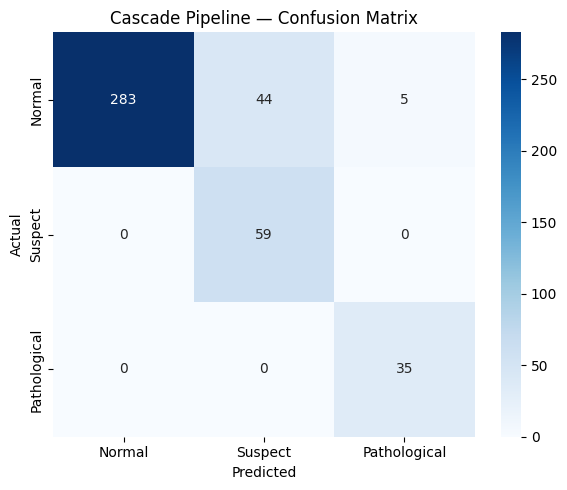

              precision    recall  f1-score   support

      Normal       1.00      0.85      0.92       332
     Suspect       0.57      1.00      0.73        59
Pathological       0.88      1.00      0.93        35

    accuracy                           0.88       426
   macro avg       0.82      0.95      0.86       426
weighted avg       0.93      0.88      0.89       426



In [9]:
# ── Confusion Matrix on Test Split ────────────────────────────────────────────
# Rebuild test split for 3-class evaluation
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(
    dff, y['fetal_health'], test_size=0.2, random_state=42, stratify=y
)

# Predict using the full cascade pipeline
y_pred_3 = []
for _, row in X_test_3.iterrows():
    case   = pd.DataFrame([row])
    p_risk = model_A.predict_proba(case).flatten()[1]
    if p_risk < RISK_THRESHOLD:
        y_pred_3.append(1)
    else:
        pred_B = int(model_B.predict(case)[0])
        y_pred_3.append(2 if pred_B == 0 else 3)

cm = confusion_matrix(y_test_3, y_pred_3, labels=[1, 2, 3])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Suspect', 'Pathological'],
            yticklabels=['Normal', 'Suspect', 'Pathological'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Cascade Pipeline — Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_test_3, y_pred_3, target_names=['Normal', 'Suspect', 'Pathological']))

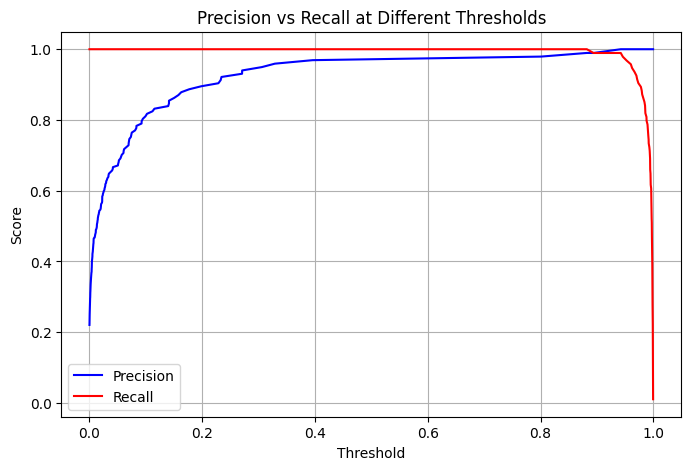

In [7]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Get probabilities on test set
y_scores = model_A.predict_proba(X_test)[:, 1]  # Risk probability

precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

plt.figure(figsize=(8,5))
plt.plot(thresholds, precisions[:-1], label='Precision', color='blue')
plt.plot(thresholds, recalls[:-1], label='Recall', color='red')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision vs Recall at Different Thresholds')
plt.legend()
plt.grid(True)
plt.show()

In [8]:
# Define costs
cost_false_negative = 50   # missing a real risk case
cost_false_positive = 1    # unnecessary extra test

total_costs = []
for i, t in enumerate(thresholds):
    fn_rate = 1 - recalls[i]
    fp_rate = 1 - precisions[i]
    cost = (fn_rate * cost_false_negative) + (fp_rate * cost_false_positive)
    total_costs.append(cost)

best_threshold_idx = np.argmin(total_costs)
best_threshold = thresholds[best_threshold_idx]
print(f"Cost-optimal threshold: {best_threshold:.4f}")

Cost-optimal threshold: 0.8821


In [9]:
import numpy as np

# Find threshold where recall is at least 0.97
target_recall = 0.97
valid_indices = np.where(recalls[:-1] >= target_recall)[0]

if len(valid_indices) > 0:
    best_idx = valid_indices[np.argmax(precisions[valid_indices])]
    best_threshold = thresholds[best_idx]
    print(f"Best threshold for recall >= {target_recall}: {best_threshold:.4f}")
    print(f"At this threshold — Precision: {precisions[best_idx]:.3f}, Recall: {recalls[best_idx]:.3f}")

Best threshold for recall >= 0.97: 0.9422
At this threshold — Precision: 1.000, Recall: 0.989
